# Neural-network SHAP feature importance

Creates SHAP importances for both NN survival models (mRNA only and integrated), using the best configurations from the tuning stage
(scripts 16 / 17):

Again we average over both: for each of `N_SEEDS` seeds we draw a newly stratified 5-fold split and seed the network init, giving 5 seeds x 5 folds = 25
trained models per network. SHAP is computed on each run's test fold, then averaged per feature.


## Imports & setup

In [12]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import CoxPH
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sksurv.metrics import concordance_index_censored
import shap

sys.path.append("../scripts")  # shared fold-safe KNN methylation imputation
from KNN_Imputation_Helper_Function import fit_transform_train_test_methylation

warnings.simplefilter("ignore")
TABLES = Path("../results/tables"); TABLES.mkdir(parents=True, exist_ok=True)
FIGURES = Path("../results/figures"); FIGURES.mkdir(parents=True, exist_ok=True)

MAX_EPOCHS   = 256
VAL_FRACTION = 0.20
OUTPUT_BIAS  = False
SHAP_BACKGROUND = 100          
N_SEEDS = 5                    
SEEDS = list(range(N_SEEDS))

## Load and align data

Same patient set as in the other models. the outer folds are drawn per seed repeatedly.

In [2]:
rna   = pd.read_csv("../data/processed/rna_pam50.csv").set_index("patient")
meth  = pd.read_csv("../data/processed/meth_pam50.csv").set_index("patient")
surv  = pd.read_csv("../data/processed/survival_luminal_clean.csv").set_index("patient")
anno  = pd.read_csv("../data/processed/cpg_gene_map.csv")
cpg_to_gene = dict(zip(anno["cpg"], anno["gene"]))

surv = surv[surv["time"].notna() & (surv["time"] > 0)]
patients = rna.index.intersection(meth.index).intersection(surv.index)
rna, meth, surv = rna.loc[patients], meth.loc[patients], surv.loc[patients]
patients_arr = np.array(rna.index)

stratum = (surv["BRCA_Subtype_PAM50"].astype(str) + "_" + surv["event"].astype(str))
strat_arr = stratum.loc[patients_arr].values
print(f"Patients: {len(patients)} | genes: {rna.shape[1]} | raw CpGs: {meth.shape[1]} "
      f"| events: {int(surv['event'].sum())} | strata: {sorted(set(strat_arr))}")

Patients: 556 | genes: 50 | raw CpGs: 572 | events: 65 | strata: ['LumA_0', 'LumA_1', 'LumB_0', 'LumB_1']


## Best configurations

Copied from scripts 16 and 17.

In [3]:
BEST_MRNA = dict(learning_rate=0.001, weight_decay=0.001, num_nodes=[16],
                 dropout=0.6, batch_norm=False, patience=10, batch_size=32)

BEST_INTEGRATED = dict(learning_rate=0.001, weight_decay=0.03, num_nodes=[8],
                       dropout=0.5, batch_norm=False, meth_variance_threshold=0.0005,
                       patience=10, batch_size=32)

METH_MISSING_THRESHOLD = 0.3
KNN_NEIGHBORS, KNN_WEIGHTS = 10, "distance"

## Neural-network helper functions.

In [13]:
def make_y(ids):
    return (surv.loc[ids, "time"].values.astype("float32"),
            surv.loc[ids, "event"].values.astype("float32"))


def build_net(in_features, num_nodes, dropout, batch_norm):
    layers, prev = [], in_features
    for n in num_nodes:
        layers += [nn.Linear(prev, n), nn.ReLU()]
        if batch_norm:
            layers.append(nn.BatchNorm1d(n))
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        prev = n
    layers.append(nn.Linear(prev, 1, bias=OUTPUT_BIAS))
    return nn.Sequential(*layers)


def build_model(in_features, learning_rate, weight_decay, num_nodes, dropout, batch_norm):
    net = build_net(in_features, num_nodes, dropout, batch_norm)
    return CoxPH(net, tt.optim.Adam(lr=learning_rate, weight_decay=weight_decay))

## Feature builders

In [14]:
def build_features_mrna(tr_ids, val_ids, test_ids):
    scaler = StandardScaler().fit(rna.loc[tr_ids])
    x_tr  = scaler.transform(rna.loc[tr_ids]).astype("float32")
    x_val = scaler.transform(rna.loc[val_ids]).astype("float32")
    x_te  = scaler.transform(rna.loc[test_ids]).astype("float32")
    feature_names = [f"RNA: {g}" for g in rna.columns]
    return x_tr, x_val, x_te, feature_names


def beta_to_m(B):
    B = B.clip(1e-4, 1 - 1e-4)
    return np.log2(B / (1 - B))


def build_features_integrated(tr_ids, val_ids, test_ids, meth_variance_threshold):
    train_raw = meth.loc[tr_ids]
    keep = ((train_raw.isna().mean() <= METH_MISSING_THRESHOLD) &
            (train_raw.var(skipna=True) >= meth_variance_threshold))
    selected = train_raw.columns[keep]
    meth_f = meth[selected]

    Bm_tr, Bm_te, _ = fit_transform_train_test_methylation(
        meth_f, tr_ids, test_ids, n_neighbors=KNN_NEIGHBORS, weights=KNN_WEIGHTS, scale=False)
    _, Bm_val, _ = fit_transform_train_test_methylation(
        meth_f, tr_ids, val_ids, n_neighbors=KNN_NEIGHBORS, weights=KNN_WEIGHTS, scale=False)

    Mm_tr, Mm_val, Mm_te = beta_to_m(Bm_tr), beta_to_m(Bm_val), beta_to_m(Bm_te)
    ms = StandardScaler().fit(Mm_tr)
    Mm_tr  = pd.DataFrame(ms.transform(Mm_tr),  index=Bm_tr.index,  columns=Mm_tr.columns)
    Mm_val = pd.DataFrame(ms.transform(Mm_val), index=Bm_val.index, columns=Mm_val.columns)
    Mm_te  = pd.DataFrame(ms.transform(Mm_te),  index=Bm_te.index,  columns=Mm_te.columns)

    rs = StandardScaler().fit(rna.loc[tr_ids])
    Xr_tr  = pd.DataFrame(rs.transform(rna.loc[tr_ids]),  index=tr_ids,  columns=rna.columns)
    Xr_val = pd.DataFrame(rs.transform(rna.loc[val_ids]), index=val_ids, columns=rna.columns)
    Xr_te  = pd.DataFrame(rs.transform(rna.loc[test_ids]),index=test_ids,columns=rna.columns)

    x_tr  = pd.concat([Xr_tr,  Mm_tr],  axis=1).to_numpy().astype("float32")
    x_val = pd.concat([Xr_val, Mm_val], axis=1).to_numpy().astype("float32")
    x_te  = pd.concat([Xr_te,  Mm_te],  axis=1).to_numpy().astype("float32")
    feature_names = ([f"RNA: {g}" for g in rna.columns] +
                     [f"METH: {cpg_to_gene.get(c, 'Unknown')} ({c})" for c in Mm_tr.columns])
    return x_tr, x_val, x_te, feature_names

## Train one run and compute SHAP

train_run reproduces the scripts per-fold training for a given seed (init + val split). shap_run
builds a DeepExplainer on a background sample of the training fold and averages |SHAP| over the test fold.


In [6]:
def train_run(seed, train_val_ids, test_ids, feature_builder, config):
    cfg = dict(config)
    meth_vt = cfg.pop("meth_variance_threshold", None)
    patience = cfg.pop("patience"); batch_size = cfg.pop("batch_size")

    tr_ids, val_ids = train_test_split(
        train_val_ids, test_size=VAL_FRACTION, random_state=seed,
        stratify=surv.loc[train_val_ids, "event"])

    if meth_vt is None:
        x_tr, x_val, x_te, names = feature_builder(tr_ids, val_ids, test_ids)
    else:
        x_tr, x_val, x_te, names = feature_builder(tr_ids, val_ids, test_ids, meth_vt)

    y_tr, y_val = make_y(tr_ids), make_y(val_ids)
    torch.manual_seed(seed)
    model = build_model(x_tr.shape[1], **cfg)
    model.fit(x_tr, y_tr, batch_size=batch_size, epochs=MAX_EPOCHS,
              callbacks=[tt.callbacks.EarlyStopping(patience=patience)],
              val_data=(x_val, y_val), val_batch_size=batch_size, verbose=False)
    return model, x_tr, x_te, names


def shap_run(model, x_tr, x_te, names, seed):
    net = model.net.eval()
    rng = np.random.RandomState(seed)
    bg_idx = rng.choice(x_tr.shape[0], size=min(SHAP_BACKGROUND, x_tr.shape[0]), replace=False)
    background = torch.tensor(x_tr[bg_idx])
    explain = torch.tensor(x_te)

    explainer = shap.DeepExplainer(net, background)
    sv = explainer.shap_values(explain, check_additivity=False)
    sv = np.array(sv)
    if sv.ndim == 3:
        sv = sv[..., 0] if sv.shape[-1] == 1 else sv[0]
    importance = np.abs(sv).mean(axis=0)     # mean |SHAP| per feature
    return dict(zip(names, importance))

## Repeated CV over seeds x folds

Features absent from a run (a CpG filtered out that fold) count as 0, so the average is over all 25
runs.

In [15]:
def repeated_shap_importance(feature_builder, config, label):
    sum_imp, n_runs = {}, 0
    for seed in SEEDS:
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        for tr_idx, te_idx in skf.split(patients_arr, strat_arr):
            train_val_ids = pd.Index(patients_arr[tr_idx])
            test_ids      = pd.Index(patients_arr[te_idx])
            model, x_tr, x_te, names = train_run(seed, train_val_ids, test_ids,
                                                 feature_builder, config)
            d = shap_run(model, x_tr, x_te, names, seed)
            n_runs += 1
            for name, v in d.items():
                sum_imp[name] = sum_imp.get(name, 0.0) + float(v)
        print(f"  {label}: seed {seed} done ({n_runs} runs so far)")
    return sum_imp, n_runs


def to_importance_table(sum_imp, n_runs, model_name):
    rows = []
    for name in sum_imp:
        modality = "METH" if name.startswith("METH") else "RNA"
        if modality == "RNA":
            gene, cpg = name.split("RNA: ")[1], np.nan
        else:
            inner = name.split("METH: ")[1]
            gene, cpg = inner.split(" (")[0], inner.split("(")[1].rstrip(")")
        rows.append({"model": model_name, "feature": name, "modality": modality,
                     "gene": gene, "cpg": cpg, "importance": sum_imp[name] / n_runs})
    df = pd.DataFrame(rows).sort_values("importance", ascending=False).reset_index(drop=True)
    df["rank"] = np.arange(1, len(df) + 1)
    return df

### mRNA-only NN

In [16]:
sum_mrna, nr = repeated_shap_importance(build_features_mrna, BEST_MRNA, "mRNA-NN")
imp_nn_mrna = to_importance_table(sum_mrna, nr, "NN_mRNA")
imp_nn_mrna.to_csv(TABLES / "feature_importance_nn_mrna.csv", index=False)
print(f"mRNA-NN aggregated over {nr} runs")
imp_nn_mrna.head(10)

  mRNA-NN: seed 0 done (5 runs so far)
  mRNA-NN: seed 1 done (10 runs so far)
  mRNA-NN: seed 2 done (15 runs so far)
  mRNA-NN: seed 3 done (20 runs so far)
  mRNA-NN: seed 4 done (25 runs so far)
mRNA-NN aggregated over 25 runs


,model,feature,modality,gene,cpg,importance,rank
0,NN_mRNA,RNA: CENPF,RNA,CENPF,NaN,0.025268,1
1,NN_mRNA,RNA: GRB7,RNA,GRB7,NaN,0.021991,2
2,NN_mRNA,RNA: KIF2C,RNA,KIF2C,NaN,0.021925,3
3,NN_mRNA,RNA: FOXC1,RNA,FOXC1,NaN,0.021753,4
4,NN_mRNA,RNA: BIRC5,RNA,BIRC5,NaN,0.021308,5
5,NN_mRNA,RNA: UBE2T,RNA,UBE2T,NaN,0.020894,6
6,NN_mRNA,RNA: EGFR,RNA,EGFR,NaN,0.020751,7
7,NN_mRNA,RNA: KRT17,RNA,KRT17,NaN,0.020024,8
8,NN_mRNA,RNA: PGR,RNA,PGR,NaN,0.019586,9
9,NN_mRNA,RNA: ORC6,RNA,ORC6,NaN,0.019320,10


### Integrated NN

In [9]:
sum_int, nri = repeated_shap_importance(build_features_integrated, BEST_INTEGRATED, "integrated-NN")
imp_nn_int = to_importance_table(sum_int, nri, "NN_integrated")
imp_nn_int.to_csv(TABLES / "feature_importance_nn_integrated.csv", index=False)
print(f"Integrated NN aggregated over {nri} runs | features seen: {len(imp_nn_int)} "
      f"({(imp_nn_int.modality=='RNA').sum()} RNA + {(imp_nn_int.modality=='METH').sum()} CpGs)")
imp_nn_int.head(10)

  integrated-NN: seed 0 done (5 runs so far)
  integrated-NN: seed 1 done (10 runs so far)
  integrated-NN: seed 2 done (15 runs so far)
  integrated-NN: seed 3 done (20 runs so far)
  integrated-NN: seed 4 done (25 runs so far)
Integrated NN aggregated over 25 runs | features seen: 340 (50 RNA + 290 CpGs)


,model,feature,modality,gene,cpg,importance,rank
0,NN_integrated,METH: MAPT (cg16520312),METH,MAPT,cg16520312,0.009200,1
1,NN_integrated,METH: ESR1 (cg23165623),METH,ESR1,cg23165623,0.008854,2
2,NN_integrated,RNA: UBE2T,RNA,UBE2T,NaN,0.008724,3
3,NN_integrated,METH: EGFR (cg05064645),METH,EGFR,cg05064645,0.008513,4
4,NN_integrated,METH: PHGDH (cg10827253),METH,PHGDH,cg10827253,0.008509,5
5,NN_integrated,METH: ESR1 (cg21614759),METH,ESR1,cg21614759,0.008499,6
6,NN_integrated,METH: FOXA1 (cg03026462),METH,FOXA1,cg03026462,0.008416,7
7,NN_integrated,RNA: KRT17,RNA,KRT17,NaN,0.008350,8
8,NN_integrated,RNA: NUF2,RNA,NUF2,NaN,0.008290,9
9,NN_integrated,METH: ESR1 (cg00655307),METH,ESR1,cg00655307,0.008288,10


### Gene-level view of the integrated model

Collapse CpGs to genes (max mean-|SHAP| across a genes features) for a compact gene level summary.

In [10]:
gene_int = (imp_nn_int.groupby("gene")
            .agg(importance=("importance", "max"),
                 modalities=("modality", lambda s: "+".join(sorted(set(s)))),
                 n_features=("feature", "size"))
            .sort_values("importance", ascending=False).reset_index())
gene_int["rank"] = np.arange(1, len(gene_int) + 1)
gene_int.to_csv(TABLES / "feature_importance_nn_integrated_gene_level.csv", index=False)
gene_int.head(15)

,gene,importance,modalities,n_features,rank
0,MAPT,0.009200,METH+RNA,3,1
1,ESR1,0.008854,METH+RNA,42,2
2,UBE2T,0.008724,METH+RNA,8,3
3,EGFR,0.008513,METH+RNA,7,4
4,PHGDH,0.008509,METH+RNA,5,5
5,FOXA1,0.008416,METH+RNA,9,6
6,KRT17,0.008350,RNA,1,7
7,NUF2,0.008290,METH+RNA,3,8
8,SFRP1,0.008276,METH+RNA,22,9
9,MIA,0.008119,METH+RNA,3,10


## Visualisation — highest SHAP values per model

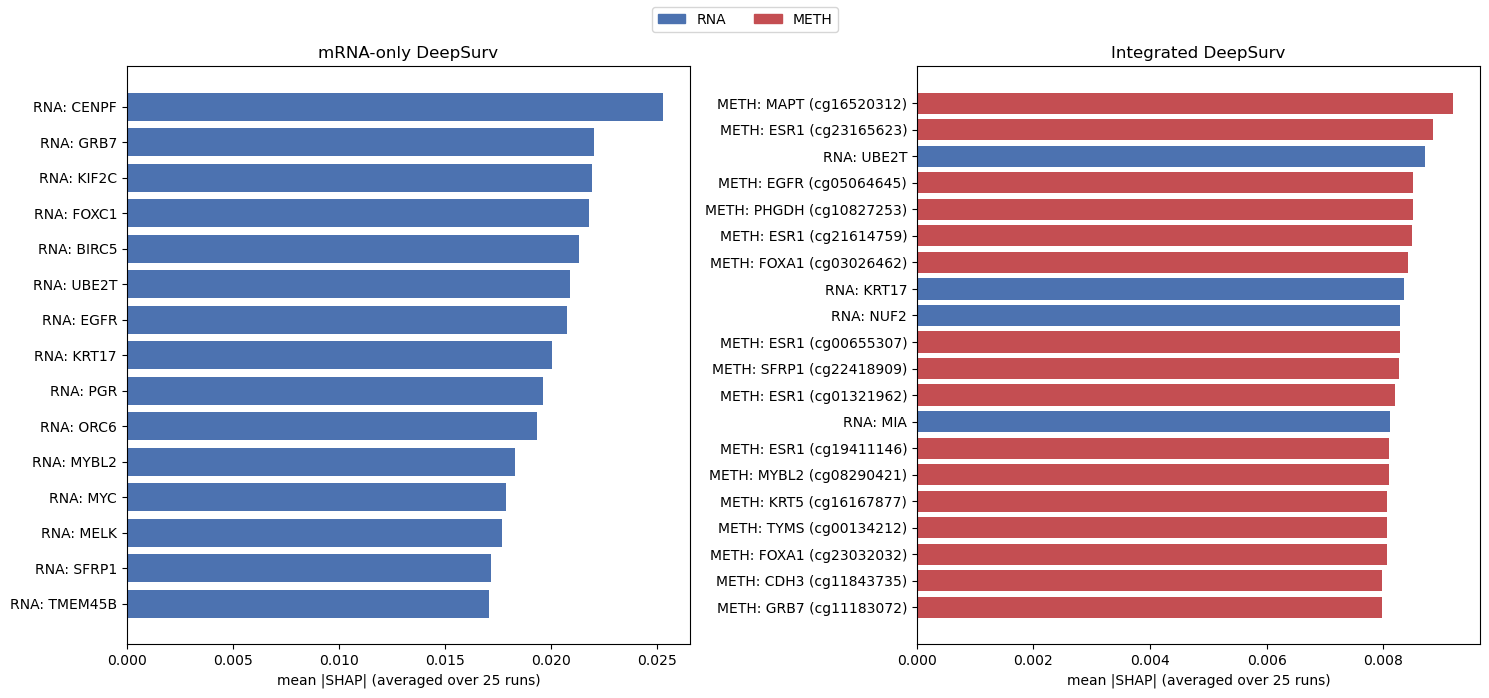

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, df, title in [
    (axes[0], imp_nn_mrna.head(15), "mRNA-only DeepSurv"),
    (axes[1], imp_nn_int.head(20), "Integrated DeepSurv"),
]:
    d = df.iloc[::-1]
    colors = ["#4C72B0" if m == "RNA" else "#C44E52" for m in d["modality"]]
    ax.barh(d["feature"], d["importance"], color=colors)
    ax.set_xlabel("mean |SHAP| (averaged over 25 runs)"); ax.set_title(title)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ("#4C72B0", "#C44E52")]
fig.legend(handles, ["RNA", "METH"], loc="upper center", ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(FIGURES / "nn_shap_feature_importance_repeatedcv.png", dpi=300)
plt.show()

## Summary

Outputs:

- `feature_importance_nn_mrna.csv`
- `feature_importance_nn_integrated.csv`
- `feature_importance_nn_integrated_gene_level.csv`
- `nn_shap_feature_importance_repeatedcv.png`